In [ ]:
# Vehicle Damage Segmentation Using YOLO

## Training a YOLO Segmentation Model on Six Vehicle-Damage Classes

This notebook presents the complete process of preparing the dataset,
validating its structure, training a YOLO segmentation model, evaluating
its performance, and saving the final trained model.

### Project objective

The objective is to train a YOLO segmentation model capable of detecting
and segmenting six types of vehicle damage.

### Main stages

1. Environment setup
2. Dataset validation
3. Class and annotation inspection
4. Model training
5. Performance evaluation
6. Prediction visualization
7. Final model export

In [ ]:
## 1. Environment Setup

In this section, the required Python packages are installed and the
runtime environment is prepared for YOLO segmentation training.

In [1]:
!pip install -q ultralytics


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os
import yaml
from pathlib import Path

import torch
from ultralytics import YOLO

In [3]:
print(f"Python: {os.sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.11.13
PyTorch: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3090


In [ ]:
## 2. Project and Dataset Configuration

This section defines the project paths, dataset locations, model checkpoint, and output directories.

A separate dataset directory will be used for the six-class YOLO segmentation dataset to avoid modifying the original data.

In [4]:
from pathlib import Path

# Main project directory
PROJECT_DIR = Path("/tf/harel yolo")

# Original CarDD dataset
SOURCE_DATASET_DIR = PROJECT_DIR / "CarDD"

# New YOLO segmentation dataset
SEG_DATASET_DIR = PROJECT_DIR / "CarDD_YOLO_SEG_6CLS"

# Dataset configuration file
DATA_YAML = SEG_DATASET_DIR / "data.yaml"

# Training output directory
RUNS_DIR = PROJECT_DIR / "runs"

# YOLO segmentation checkpoint
MODEL_NAME = "yolo11s-seg.pt"

# Training run name
RUN_NAME = "cardd_yolo11s_seg_6classes"

print("Project directory:", PROJECT_DIR)
print("Source dataset:", SOURCE_DATASET_DIR)
print("Segmentation dataset:", SEG_DATASET_DIR)
print("Dataset YAML:", DATA_YAML)
print("Model:", MODEL_NAME)
print("Run name:", RUN_NAME)

Project directory: /tf/harel yolo
Source dataset: /tf/harel yolo/CarDD
Segmentation dataset: /tf/harel yolo/CarDD_YOLO_SEG_6CLS
Dataset YAML: /tf/harel yolo/CarDD_YOLO_SEG_6CLS/data.yaml
Model: yolo11s-seg.pt
Run name: cardd_yolo11s_seg_6classes


In [ ]:
## 3. Source Dataset Inspection

Before converting the dataset, the original directory structure and annotation files must be inspected.

This step verifies that the required images and polygon segmentation annotations are available.

In [5]:
if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project directory was not found: {PROJECT_DIR}")

if not SOURCE_DATASET_DIR.exists():
    raise FileNotFoundError(f"Source dataset was not found: {SOURCE_DATASET_DIR}")

print("Project directory exists.")
print("Source dataset directory exists.")

Project directory exists.
Source dataset directory exists.


In [6]:
def show_directory_structure(root: Path, max_depth: int = 3) -> None:
    root = Path(root)

    for path in sorted(root.rglob("*")):
        try:
            depth = len(path.relative_to(root).parts)
        except ValueError:
            continue

        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "📁" if path.is_dir() else "📄"
        print(f"{indent}{marker} {path.name}")


show_directory_structure(SOURCE_DATASET_DIR, max_depth=3)

📁 CarDD_release
    📁 CarDD_COCO
        📁 annotations
        📁 test2017
        📁 train2017
        📁 val2017
    📁 CarDD_SOD
        📁 CarDD-TE
        📁 CarDD-TR
        📁 CarDD-VAL


In [7]:
annotation_files = []

for extension in ("*.json", "*.yaml", "*.yml", "*.txt"):
    annotation_files.extend(SOURCE_DATASET_DIR.rglob(extension))

print(f"Annotation/configuration files found: {len(annotation_files)}")

for path in sorted(annotation_files)[:50]:
    print(path)

Annotation/configuration files found: 3
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/annotations/instances_test2017.json
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/annotations/instances_val2017.json


In [8]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    path
    for path in SOURCE_DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total source images found: {len(image_files)}")

for path in sorted(image_files)[:10]:
    print(path)

Total source images found: 16000
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000012.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000015.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000023.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000033.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000040.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000042.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000044.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000057.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000082.jpg
/tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017/000088.jpg


In [ ]:
## 4. COCO Annotation Validation

The COCO annotation files are inspected to verify the dataset classes, image counts, annotation counts, and polygon segmentation availability.

This step ensures that the dataset is suitable for YOLO segmentation training before conversion.

In [9]:
import json
from collections import Counter

COCO_DIR = SOURCE_DATASET_DIR / "CarDD_release" / "CarDD_COCO"
ANNOTATIONS_DIR = COCO_DIR / "annotations"

SPLIT_PATHS = {
    "train": {
        "images": COCO_DIR / "train2017",
        "annotations": ANNOTATIONS_DIR / "instances_train2017.json",
    },
    "val": {
        "images": COCO_DIR / "val2017",
        "annotations": ANNOTATIONS_DIR / "instances_val2017.json",
    },
    "test": {
        "images": COCO_DIR / "test2017",
        "annotations": ANNOTATIONS_DIR / "instances_test2017.json",
    },
}

for split_name, paths in SPLIT_PATHS.items():
    print(f"{split_name}:")
    print("  Images directory:", paths["images"])
    print("  Annotation file:", paths["annotations"])
    print("  Images directory exists:", paths["images"].exists())
    print("  Annotation file exists:", paths["annotations"].exists())

train:
  Images directory: /tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/train2017
  Annotation file: /tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
  Images directory exists: True
  Annotation file exists: True
val:
  Images directory: /tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/val2017
  Annotation file: /tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/annotations/instances_val2017.json
  Images directory exists: True
  Annotation file exists: True
test:
  Images directory: /tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/test2017
  Annotation file: /tf/harel yolo/CarDD/CarDD_release/CarDD_COCO/annotations/instances_test2017.json
  Images directory exists: True
  Annotation file exists: True


In [10]:
with open(SPLIT_PATHS["train"]["annotations"], "r", encoding="utf-8") as file:
    train_coco = json.load(file)

categories = sorted(train_coco["categories"], key=lambda category: category["id"])

print(f"Number of categories: {len(categories)}")
print()

for category in categories:
    print(
        f"COCO ID: {category['id']} | "
        f"Name: {category['name']} | "
        f"Supercategory: {category.get('supercategory', 'N/A')}"
    )

Number of categories: 6

COCO ID: 1 | Name: dent | Supercategory: N/A
COCO ID: 2 | Name: scratch | Supercategory: N/A
COCO ID: 3 | Name: crack | Supercategory: N/A
COCO ID: 4 | Name: glass shatter | Supercategory: N/A
COCO ID: 5 | Name: lamp broken | Supercategory: N/A
COCO ID: 6 | Name: tire flat | Supercategory: N/A


In [11]:
def inspect_coco_split(split_name: str, annotation_path: Path) -> dict:
    with open(annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    category_names = {
        category["id"]: category["name"]
        for category in coco_data["categories"]
    }

    class_counts = Counter(
        annotation["category_id"]
        for annotation in coco_data["annotations"]
    )

    polygon_annotations = 0
    rle_annotations = 0
    empty_segmentations = 0
    multi_polygon_annotations = 0

    for annotation in coco_data["annotations"]:
        segmentation = annotation.get("segmentation")

        if not segmentation:
            empty_segmentations += 1
        elif isinstance(segmentation, list):
            polygon_annotations += 1

            if len(segmentation) > 1:
                multi_polygon_annotations += 1

        elif isinstance(segmentation, dict):
            rle_annotations += 1

    print(f"Split: {split_name}")
    print(f"Images in JSON: {len(coco_data['images'])}")
    print(f"Annotations: {len(coco_data['annotations'])}")
    print(f"Categories: {len(coco_data['categories'])}")
    print(f"Polygon annotations: {polygon_annotations}")
    print(f"RLE annotations: {rle_annotations}")
    print(f"Empty segmentations: {empty_segmentations}")
    print(f"Multi-polygon annotations: {multi_polygon_annotations}")
    print()

    print("Annotations per class:")

    for category_id, category_name in sorted(category_names.items()):
        print(
            f"  {category_name}: "
            f"{class_counts.get(category_id, 0)}"
        )

    return {
        "images": len(coco_data["images"]),
        "annotations": len(coco_data["annotations"]),
        "categories": len(coco_data["categories"]),
        "polygon_annotations": polygon_annotations,
        "rle_annotations": rle_annotations,
        "empty_segmentations": empty_segmentations,
        "multi_polygon_annotations": multi_polygon_annotations,
    }

In [12]:
split_statistics = {}

for split_name, paths in SPLIT_PATHS.items():
    split_statistics[split_name] = inspect_coco_split(
        split_name=split_name,
        annotation_path=paths["annotations"],
    )

    print("-" * 60)

Split: train
Images in JSON: 2816
Annotations: 6211
Categories: 6
Polygon annotations: 6211
RLE annotations: 0
Empty segmentations: 0
Multi-polygon annotations: 0

Annotations per class:
  dent: 1806
  scratch: 2560
  crack: 651
  glass shatter: 475
  lamp broken: 494
  tire flat: 225
------------------------------------------------------------
Split: val
Images in JSON: 810
Annotations: 1744
Categories: 6
Polygon annotations: 1744
RLE annotations: 0
Empty segmentations: 0
Multi-polygon annotations: 0

Annotations per class:
  dent: 501
  scratch: 728
  crack: 177
  glass shatter: 135
  lamp broken: 141
  tire flat: 62
------------------------------------------------------------
Split: test
Images in JSON: 374
Annotations: 785
Categories: 6
Polygon annotations: 785
RLE annotations: 0
Empty segmentations: 0
Multi-polygon annotations: 0

Annotations per class:
  dent: 236
  scratch: 307
  crack: 70
  glass shatter: 71
  lamp broken: 69
  tire flat: 32
------------------------------------

In [ ]:
## 5. Dataset Validation Summary

The dataset validation confirms that all annotation files are valid and suitable for YOLO segmentation training.

Validation results:

- Six damage categories are available.
- All annotations use polygon segmentation.
- No RLE masks were found.
- No empty segmentation annotations were detected.
- No multi-polygon objects were found.

The dataset is therefore ready for conversion to the YOLO segmentation format.

In [13]:
split_statistics = {}

for split_name, paths in SPLIT_PATHS.items():
    split_statistics[split_name] = inspect_coco_split(
        split_name=split_name,
        annotation_path=paths["annotations"],
    )

    print("-" * 60)

Split: train
Images in JSON: 2816
Annotations: 6211
Categories: 6
Polygon annotations: 6211
RLE annotations: 0
Empty segmentations: 0
Multi-polygon annotations: 0

Annotations per class:
  dent: 1806
  scratch: 2560
  crack: 651
  glass shatter: 475
  lamp broken: 494
  tire flat: 225
------------------------------------------------------------
Split: val
Images in JSON: 810
Annotations: 1744
Categories: 6
Polygon annotations: 1744
RLE annotations: 0
Empty segmentations: 0
Multi-polygon annotations: 0

Annotations per class:
  dent: 501
  scratch: 728
  crack: 177
  glass shatter: 135
  lamp broken: 141
  tire flat: 62
------------------------------------------------------------
Split: test
Images in JSON: 374
Annotations: 785
Categories: 6
Polygon annotations: 785
RLE annotations: 0
Empty segmentations: 0
Multi-polygon annotations: 0

Annotations per class:
  dent: 236
  scratch: 307
  crack: 70
  glass shatter: 71
  lamp broken: 69
  tire flat: 32
------------------------------------

In [14]:
for split_name, paths in SPLIT_PATHS.items():
    image_count = sum(
        1
        for path in paths["images"].iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    json_image_count = split_statistics[split_name]["images"]

    print(
        f"{split_name}: "
        f"{image_count} image files | "
        f"{json_image_count} images in JSON"
    )

    if image_count != json_image_count:
        print("  Warning: image-file count does not match JSON image count.")

train: 2816 image files | 2816 images in JSON
val: 810 image files | 810 images in JSON
test: 374 image files | 374 images in JSON


In [ ]:
## 6. Convert COCO Annotations to YOLO Segmentation Format

The original CarDD annotations are stored in COCO polygon format.

In this section, the dataset is converted into the YOLO segmentation format. Each annotation line will contain:

- The zero-based class identifier
- Normalized polygon coordinates
- One text file for each image

The original dataset will not be modified.

In [15]:
import shutil

YOLO_SPLITS = {
    "train": "train",
    "val": "val",
    "test": "test",
}

for split_name in YOLO_SPLITS:
    images_dir = SEG_DATASET_DIR / "images" / split_name
    labels_dir = SEG_DATASET_DIR / "labels" / split_name

    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

print("YOLO segmentation directory structure created:")
show_directory_structure(SEG_DATASET_DIR, max_depth=3)

YOLO segmentation directory structure created:
📁 images
    📁 test
    📁 train
    📁 val
📁 labels
    📁 test
    📁 train
    📁 val


In [16]:
with open(SPLIT_PATHS["train"]["annotations"], "r", encoding="utf-8") as file:
    train_coco = json.load(file)

categories = sorted(
    train_coco["categories"],
    key=lambda category: category["id"],
)

COCO_TO_YOLO_CLASS = {
    category["id"]: yolo_id
    for yolo_id, category in enumerate(categories)
}

CLASS_NAMES = [
    category["name"]
    for category in categories
]

print("Class mapping:")
print()

for category in categories:
    coco_id = category["id"]
    yolo_id = COCO_TO_YOLO_CLASS[coco_id]

    print(
        f"COCO ID {coco_id} -> "
        f"YOLO ID {yolo_id}: "
        f"{category['name']}"
    )

assert len(CLASS_NAMES) == 6, (
    f"Expected 6 classes, but found {len(CLASS_NAMES)}"
)

Class mapping:

COCO ID 1 -> YOLO ID 0: dent
COCO ID 2 -> YOLO ID 1: scratch
COCO ID 3 -> YOLO ID 2: crack
COCO ID 4 -> YOLO ID 3: glass shatter
COCO ID 5 -> YOLO ID 4: lamp broken
COCO ID 6 -> YOLO ID 5: tire flat


In [ ]:
### 6.2 COCO-to-YOLO Segmentation Conversion

Polygon coordinates in COCO format are stored as absolute pixel positions.

YOLO segmentation requires normalized polygon coordinates in the range 0 to 1. Each x-coordinate is divided by the image width, and each y-coordinate is divided by the image height.

In [17]:
from collections import defaultdict


def normalize_polygon(
    polygon: list,
    image_width: int,
    image_height: int,
) -> list[float]:
    """
    Convert an absolute COCO polygon to normalized YOLO coordinates.
    """

    if len(polygon) < 6 or len(polygon) % 2 != 0:
        raise ValueError(
            "A valid polygon must contain at least three x-y points."
        )

    normalized = []

    for index in range(0, len(polygon), 2):
        x = float(polygon[index])
        y = float(polygon[index + 1])

        x_normalized = min(max(x / image_width, 0.0), 1.0)
        y_normalized = min(max(y / image_height, 0.0), 1.0)

        normalized.extend([x_normalized, y_normalized])

    return normalized

In [18]:
def convert_coco_split_to_yolo_segmentation(
    split_name: str,
    source_images_dir: Path,
    annotation_path: Path,
    destination_images_dir: Path,
    destination_labels_dir: Path,
) -> dict:
    """
    Convert one COCO split into YOLO segmentation format.
    """

    with open(annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    images_by_id = {
        image["id"]: image
        for image in coco_data["images"]
    }

    annotations_by_image = defaultdict(list)

    for annotation in coco_data["annotations"]:
        annotations_by_image[annotation["image_id"]].append(annotation)

    converted_annotations = 0
    skipped_annotations = 0
    missing_images = 0
    empty_label_files = 0

    for image_id, image_info in images_by_id.items():
        file_name = image_info["file_name"]
        image_width = int(image_info["width"])
        image_height = int(image_info["height"])

        source_image_path = source_images_dir / file_name
        destination_image_path = destination_images_dir / file_name
        destination_label_path = (
            destination_labels_dir / Path(file_name).with_suffix(".txt").name
        )

        if not source_image_path.exists():
            print(f"Missing image: {source_image_path}")
            missing_images += 1
            continue

        shutil.copy2(source_image_path, destination_image_path)

        label_lines = []

        for annotation in annotations_by_image.get(image_id, []):
            coco_category_id = annotation["category_id"]
            yolo_class_id = COCO_TO_YOLO_CLASS[coco_category_id]

            segmentation = annotation.get("segmentation", [])

            if not isinstance(segmentation, list) or len(segmentation) == 0:
                skipped_annotations += 1
                continue

            # The current dataset inspection showed one polygon per annotation.
            polygon = segmentation[0]

            try:
                normalized_polygon = normalize_polygon(
                    polygon=polygon,
                    image_width=image_width,
                    image_height=image_height,
                )
            except ValueError:
                skipped_annotations += 1
                continue

            coordinates_text = " ".join(
                f"{coordinate:.6f}"
                for coordinate in normalized_polygon
            )

            label_lines.append(
                f"{yolo_class_id} {coordinates_text}"
            )

            converted_annotations += 1

        if not label_lines:
            empty_label_files += 1

        destination_label_path.write_text(
            "\n".join(label_lines),
            encoding="utf-8",
        )

    return {
        "split": split_name,
        "images_in_json": len(images_by_id),
        "annotations_in_json": len(coco_data["annotations"]),
        "converted_annotations": converted_annotations,
        "skipped_annotations": skipped_annotations,
        "missing_images": missing_images,
        "empty_label_files": empty_label_files,
    }

In [ ]:
### 6.3 Convert All Dataset Splits

The train, validation, and test splits are converted independently while preserving their original separation.

In [19]:
conversion_results = {}

for split_name, paths in SPLIT_PATHS.items():
    print(f"Converting {split_name} split...")

    result = convert_coco_split_to_yolo_segmentation(
        split_name=split_name,
        source_images_dir=paths["images"],
        annotation_path=paths["annotations"],
        destination_images_dir=SEG_DATASET_DIR / "images" / split_name,
        destination_labels_dir=SEG_DATASET_DIR / "labels" / split_name,
    )

    conversion_results[split_name] = result

    print(result)
    print("-" * 60)

Converting train split...
{'split': 'train', 'images_in_json': 2816, 'annotations_in_json': 6211, 'converted_annotations': 6211, 'skipped_annotations': 0, 'missing_images': 0, 'empty_label_files': 0}
------------------------------------------------------------
Converting val split...
{'split': 'val', 'images_in_json': 810, 'annotations_in_json': 1744, 'converted_annotations': 1744, 'skipped_annotations': 0, 'missing_images': 0, 'empty_label_files': 0}
------------------------------------------------------------
Converting test split...
{'split': 'test', 'images_in_json': 374, 'annotations_in_json': 785, 'converted_annotations': 785, 'skipped_annotations': 0, 'missing_images': 0, 'empty_label_files': 0}
------------------------------------------------------------


In [ ]:
## 7. Create the YOLO Dataset Configuration

The converted dataset is configured using a YAML file that defines the dataset paths and the six segmentation classes.

In [20]:
dataset_yaml = {
    "path": str(SEG_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": {
        class_id: class_name
        for class_id, class_name in enumerate(CLASS_NAMES)
    },
}

with open(DATA_YAML, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        dataset_yaml,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print(f"Dataset YAML created: {DATA_YAML}")
print()

with open(DATA_YAML, "r", encoding="utf-8") as file:
    print(file.read())

Dataset YAML created: /tf/harel yolo/CarDD_YOLO_SEG_6CLS/data.yaml

path: /tf/harel yolo/CarDD_YOLO_SEG_6CLS
train: images/train
val: images/val
test: images/test
nc: 6
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



In [ ]:
## 8. Validate the Converted YOLO Segmentation Dataset

Before training, the converted image and label directories are checked to verify that every image has a corresponding label file and that all class identifiers are valid.

In [21]:
def validate_yolo_segmentation_split(
    dataset_dir: Path,
    split_name: str,
    number_of_classes: int,
) -> dict:
    images_dir = dataset_dir / "images" / split_name
    labels_dir = dataset_dir / "labels" / split_name

    image_files = sorted(
        path
        for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    label_files = sorted(labels_dir.glob("*.txt"))

    missing_labels = []
    invalid_lines = []
    class_counts = Counter()
    total_objects = 0

    for image_path in image_files:
        label_path = labels_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels.append(image_path.name)
            continue

        lines = [
            line.strip()
            for line in label_path.read_text(encoding="utf-8").splitlines()
            if line.strip()
        ]

        for line_number, line in enumerate(lines, start=1):
            values = line.split()

            if len(values) < 7:
                invalid_lines.append(
                    f"{label_path.name}, line {line_number}: "
                    "fewer than three polygon points"
                )
                continue

            try:
                class_id = int(values[0])
                coordinates = [float(value) for value in values[1:]]
            except ValueError:
                invalid_lines.append(
                    f"{label_path.name}, line {line_number}: invalid numeric value"
                )
                continue

            if class_id < 0 or class_id >= number_of_classes:
                invalid_lines.append(
                    f"{label_path.name}, line {line_number}: "
                    f"invalid class ID {class_id}"
                )
                continue

            if len(coordinates) % 2 != 0:
                invalid_lines.append(
                    f"{label_path.name}, line {line_number}: "
                    "odd number of coordinates"
                )
                continue

            if any(coordinate < 0.0 or coordinate > 1.0 for coordinate in coordinates):
                invalid_lines.append(
                    f"{label_path.name}, line {line_number}: "
                    "coordinate outside the range 0-1"
                )
                continue

            class_counts[class_id] += 1
            total_objects += 1

    print(f"Split: {split_name}")
    print(f"Images: {len(image_files)}")
    print(f"Labels: {len(label_files)}")
    print(f"Objects: {total_objects}")
    print(f"Missing labels: {len(missing_labels)}")
    print(f"Invalid annotation lines: {len(invalid_lines)}")

    print("Objects per class:")
    for class_id, class_name in enumerate(CLASS_NAMES):
        print(f"  {class_id} - {class_name}: {class_counts[class_id]}")

    return {
        "images": len(image_files),
        "labels": len(label_files),
        "objects": total_objects,
        "missing_labels": missing_labels,
        "invalid_lines": invalid_lines,
        "class_counts": class_counts,
    }

In [22]:
validation_results = {}

for split_name in ("train", "val", "test"):
    validation_results[split_name] = validate_yolo_segmentation_split(
        dataset_dir=SEG_DATASET_DIR,
        split_name=split_name,
        number_of_classes=len(CLASS_NAMES),
    )

    print("-" * 60)

Split: train
Images: 2816
Labels: 2816
Objects: 6211
Missing labels: 0
Invalid annotation lines: 0
Objects per class:
  0 - dent: 1806
  1 - scratch: 2560
  2 - crack: 651
  3 - glass shatter: 475
  4 - lamp broken: 494
  5 - tire flat: 225
------------------------------------------------------------
Split: val
Images: 810
Labels: 810
Objects: 1744
Missing labels: 0
Invalid annotation lines: 0
Objects per class:
  0 - dent: 501
  1 - scratch: 728
  2 - crack: 177
  3 - glass shatter: 135
  4 - lamp broken: 141
  5 - tire flat: 62
------------------------------------------------------------
Split: test
Images: 374
Labels: 374
Objects: 785
Missing labels: 0
Invalid annotation lines: 0
Objects per class:
  0 - dent: 236
  1 - scratch: 307
  2 - crack: 70
  3 - glass shatter: 71
  4 - lamp broken: 69
  5 - tire flat: 32
------------------------------------------------------------


In [ ]:
## 9. Visualize YOLO Segmentation Annotations

Before training, several converted samples are visualized to verify that the segmentation polygons align correctly with the vehicle damage regions.

This step confirms that the class identifiers and normalized polygon coordinates were converted correctly.

In [23]:
import random
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

In [24]:
def visualize_yolo_segmentation_sample(
    image_path: Path,
    label_path: Path,
    class_names: list[str],
) -> None:
    """
    Display one image with its YOLO segmentation polygons.
    """

    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image, "RGBA")

    image_width, image_height = image.size

    label_lines = [
        line.strip()
        for line in label_path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]

    for line in label_lines:
        values = line.split()

        class_id = int(values[0])
        coordinates = [float(value) for value in values[1:]]

        polygon_points = []

        for index in range(0, len(coordinates), 2):
            x = coordinates[index] * image_width
            y = coordinates[index + 1] * image_height
            polygon_points.append((x, y))

        draw.polygon(
            polygon_points,
            fill=(255, 0, 0, 70),
            outline=(255, 0, 0, 255),
        )

        first_x, first_y = polygon_points[0]

        draw.text(
            (first_x, first_y),
            class_names[class_id],
            fill=(255, 255, 0, 255),
        )

    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.title(
        f"{image_path.name} | "
        f"Objects: {len(label_lines)}"
    )
    plt.axis("off")
    plt.show()

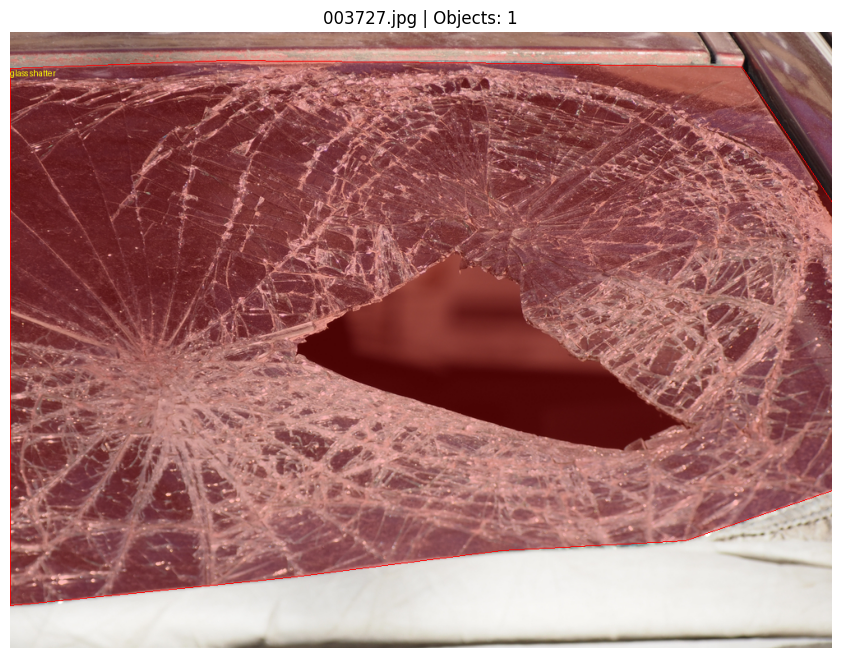

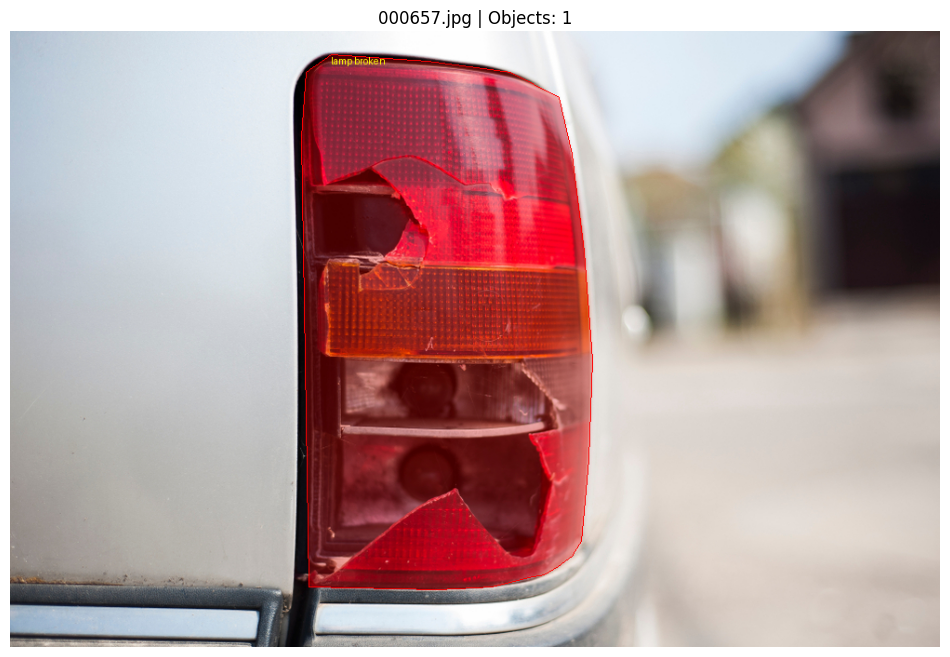

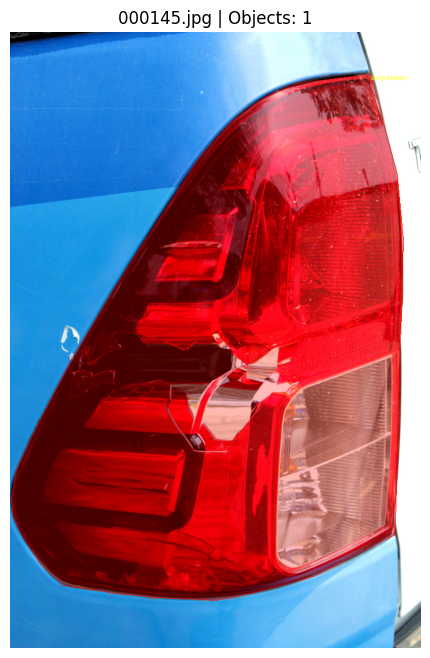

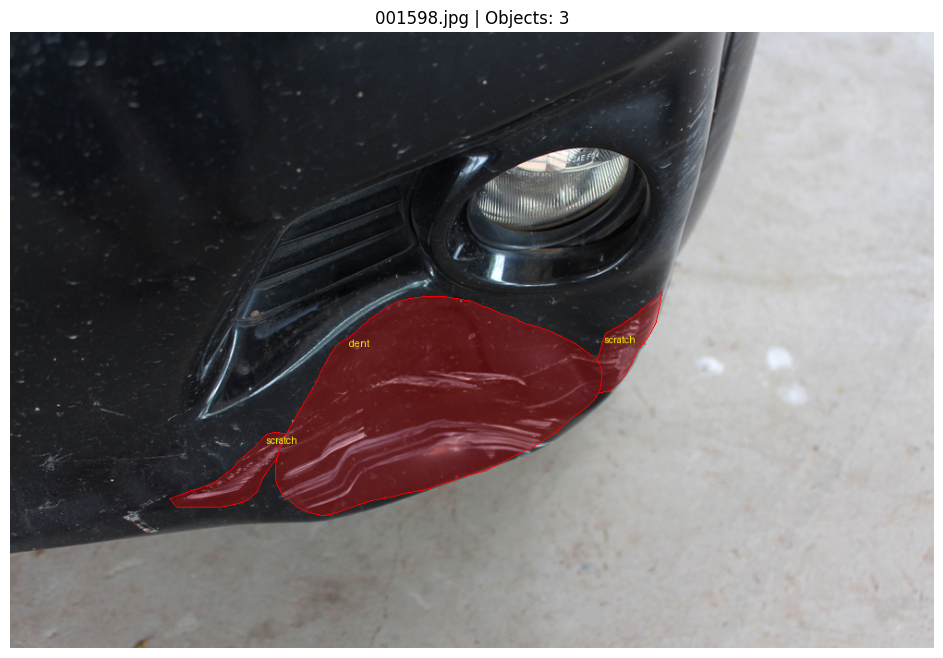

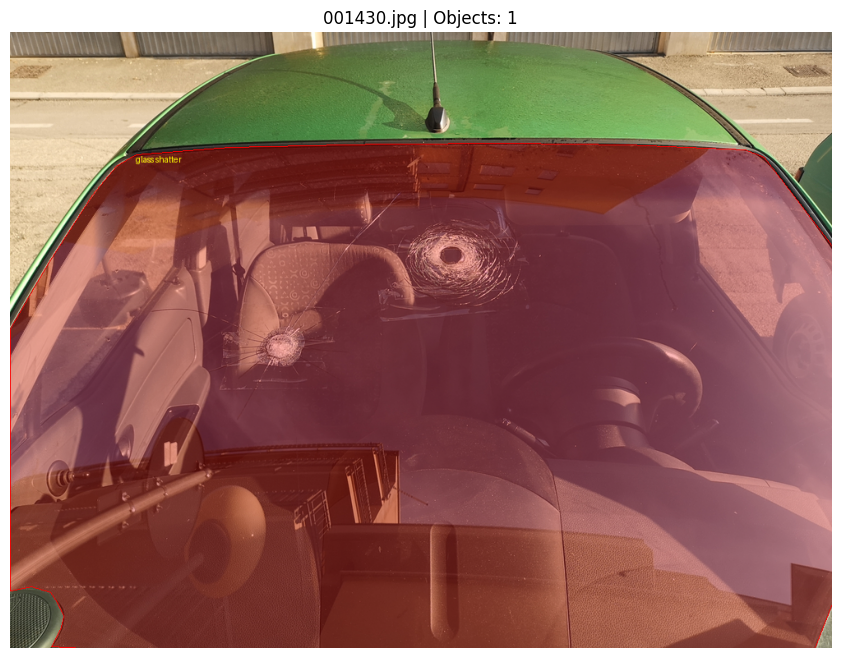

In [26]:
TRAIN_IMAGES_DIR = SEG_DATASET_DIR / "images" / "train"
TRAIN_LABELS_DIR = SEG_DATASET_DIR / "labels" / "train"

train_image_files = sorted(
    path
    for path in TRAIN_IMAGES_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

random.seed(42)

sample_images = random.sample(
    train_image_files,
    k=min(5, len(train_image_files)),
)

for image_path in sample_images:
    label_path = TRAIN_LABELS_DIR / f"{image_path.stem}.txt"

    visualize_yolo_segmentation_sample(
        image_path=image_path,
        label_path=label_path,
        class_names=CLASS_NAMES,
    )

In [ ]:
## 10. Training Configuration

This section defines the training parameters used for the YOLO11 segmentation model.

The selected configuration aims to balance segmentation accuracy and training efficiency.

In [31]:
TRAIN_CONFIG = {
    "model": MODEL_NAME,
    "data": str(DATA_YAML),

    "epochs": 100,
    "imgsz": 1024,
    "batch": 4,

    "device": 0,
    "workers": 0,

    "cache": False,
    "patience": 30,

    "optimizer": "auto",

    "project": str(RUNS_DIR),
    "name": RUN_NAME,

    "exist_ok": True,

    "verbose": True,
}

In [32]:
print("Training configuration\n")

for key, value in TRAIN_CONFIG.items():
    print(f"{key:12}: {value}")

Training configuration

model       : yolo11s-seg.pt
data        : /tf/harel yolo/CarDD_YOLO_SEG_6CLS/data.yaml
epochs      : 100
imgsz       : 1024
batch       : 4
device      : 0
workers     : 0
cache       : False
patience    : 30
optimizer   : auto
project     : /tf/harel yolo/runs
name        : cardd_yolo11s_seg_6classes
exist_ok    : True
verbose     : True


In [34]:
model = YOLO(TRAIN_CONFIG["model"])

In [ ]:
## 11. Train the YOLO11 Segmentation Model

The model is initialized from the official pretrained YOLO11 segmentation checkpoint and trained on the converted six-class dataset.

During training, the best-performing model according to the validation metrics will automatically be saved.

In [ ]:
results = model.train(
    data=TRAIN_CONFIG["data"],
    epochs=TRAIN_CONFIG["epochs"],
    imgsz=TRAIN_CONFIG["imgsz"],
    batch=TRAIN_CONFIG["batch"],
    device=TRAIN_CONFIG["device"],
    workers=TRAIN_CONFIG["workers"],
    cache=TRAIN_CONFIG["cache"],
    patience=TRAIN_CONFIG["patience"],
    optimizer=TRAIN_CONFIG["optimizer"],
    project=TRAIN_CONFIG["project"],
    name=TRAIN_CONFIG["name"],
    exist_ok=TRAIN_CONFIG["exist_ok"],
    verbose=TRAIN_CONFIG["verbose"],
)

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.99 🚀 Python-3.11.13 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24049MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tf/harel yolo/CarDD_YOLO_SEG_6CLS/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt,

In [ ]:
## 12. Training Results Analysis

This section analyzes the completed training run, identifies the best epoch, displays the training curves, and locates the final model checkpoints.

In [36]:
RUN_DIR = RUNS_DIR / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"

BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"
RESULTS_CSV_PATH = RUN_DIR / "results.csv"

print("Run directory:", RUN_DIR)
print("Best model exists:", BEST_MODEL_PATH.exists())
print("Last model exists:", LAST_MODEL_PATH.exists())
print("Results CSV exists:", RESULTS_CSV_PATH.exists())

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"best.pt was not found: {BEST_MODEL_PATH}")

Run directory: /tf/harel yolo/runs/cardd_yolo11s_seg_6classes
Best model exists: True
Last model exists: True
Results CSV exists: True


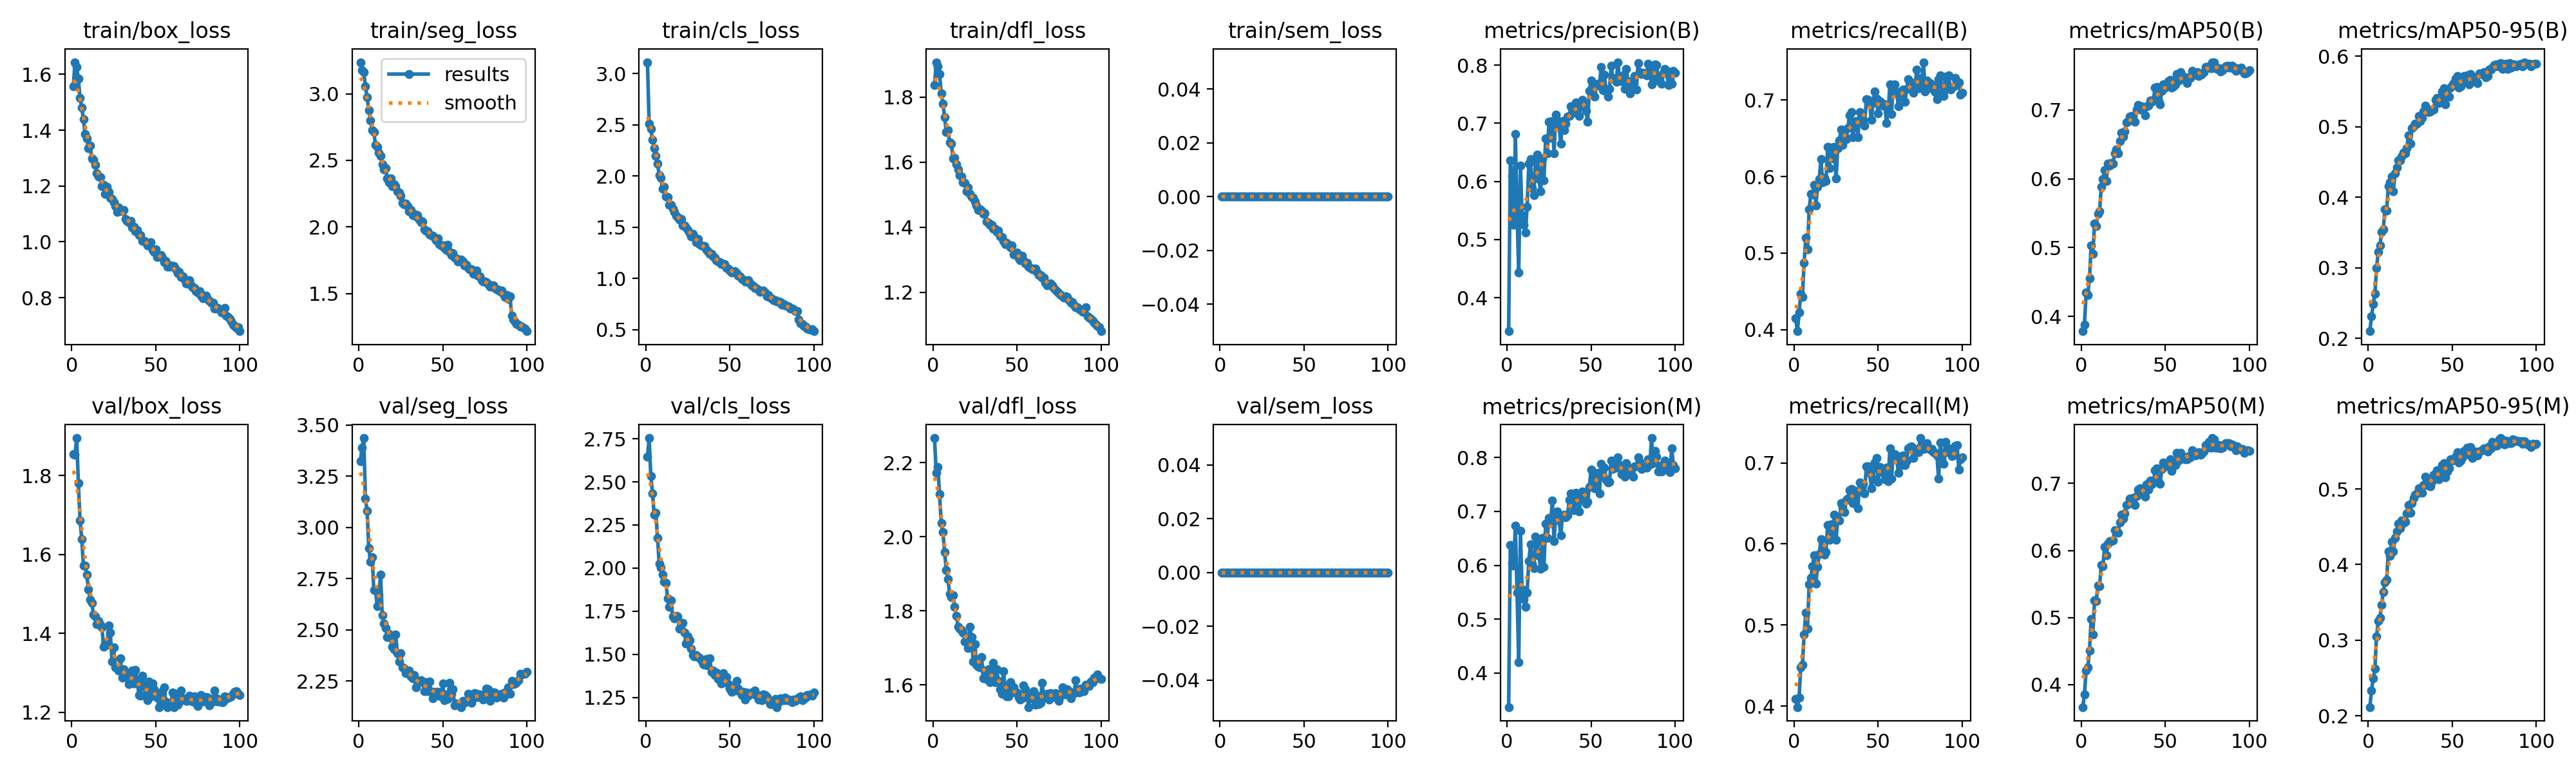

In [37]:
from IPython.display import display
from PIL import Image

results_plot_path = RUN_DIR / "results.png"

if results_plot_path.exists():
    display(Image.open(results_plot_path))
else:
    print("results.png was not found.")

In [38]:
import pandas as pd

results_df = pd.read_csv(RESULTS_CSV_PATH)

# Remove spaces that Ultralytics may add to column names
results_df.columns = results_df.columns.str.strip()

print("Number of completed epochs:", len(results_df))
print("Available columns:")
for column in results_df.columns:
    print(" -", column)

display(results_df.tail())

Number of completed epochs: 100
Available columns:
 - epoch
 - time
 - train/box_loss
 - train/seg_loss
 - train/cls_loss
 - train/dfl_loss
 - train/sem_loss
 - metrics/precision(B)
 - metrics/recall(B)
 - metrics/mAP50(B)
 - metrics/mAP50-95(B)
 - metrics/precision(M)
 - metrics/recall(M)
 - metrics/mAP50(M)
 - metrics/mAP50-95(M)
 - val/box_loss
 - val/seg_loss
 - val/cls_loss
 - val/dfl_loss
 - val/sem_loss
 - lr/pg0
 - lr/pg1
 - lr/pg2


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
95,96,16257.9,0.70337,1.25133,0.51087,1.10735,0,0.76523,0.72913,0.75637,...,0.75178,0.55850,1.24700,2.28582,1.26386,1.61844,0,0.00006,0.00006,0.00006
96,97,16423.4,0.69806,1.25202,0.50511,1.10069,0,0.77700,0.72045,0.75336,...,0.74530,0.55579,1.25271,2.28185,1.26487,1.62007,0,0.00005,0.00005,0.00005
97,98,16589.5,0.69154,1.24203,0.50037,1.09622,0,0.76837,0.72331,0.75335,...,0.74889,0.55929,1.25453,2.28453,1.26579,1.62804,0,0.00004,0.00004,0.00004
98,99,16755.3,0.69458,1.23526,0.50516,1.09313,0,0.78953,0.70724,0.75505,...,0.74925,0.55918,1.24698,2.28621,1.25984,1.61745,0,0.00003,0.00003,0.00003
99,100,16921.0,0.67961,1.21600,0.48421,1.08034,0,0.78714,0.70967,0.75738,...,0.74837,0.55940,1.24350,2.29526,1.27713,1.61584,0,0.00002,0.00002,0.00002


In [39]:
mask_map_column = "metrics/mAP50-95(M)"

if mask_map_column not in results_df.columns:
    raise KeyError(
        f"Column '{mask_map_column}' was not found. "
        f"Available columns: {list(results_df.columns)}"
    )

best_row_index = results_df[mask_map_column].idxmax()
best_row = results_df.loc[best_row_index]

best_epoch = int(best_row["epoch"]) + 1

print(f"Best epoch: {best_epoch}")
print()

important_metrics = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
    "metrics/precision(M)",
    "metrics/recall(M)",
    "metrics/mAP50(M)",
    "metrics/mAP50-95(M)",
]

for metric in important_metrics:
    if metric in best_row:
        print(f"{metric}: {best_row[metric]:.4f}")

Best epoch: 80

metrics/precision(B): 0.7881
metrics/recall(B): 0.7257
metrics/mAP50(B): 0.7693
metrics/mAP50-95(B): 0.5905
metrics/precision(M): 0.7920
metrics/recall(M): 0.7246
metrics/mAP50(M): 0.7656
metrics/mAP50-95(M): 0.5673


In [ ]:
## 13. Evaluate the Best Model on the Test Set

The best checkpoint is evaluated on the independent test split. Both object-detection and segmentation metrics are reported.

In [40]:
best_model = YOLO(str(BEST_MODEL_PATH))

print("Loaded model:", BEST_MODEL_PATH)
print("Task:", best_model.task)
print("Classes:", best_model.names)

Loaded model: /tf/harel yolo/runs/cardd_yolo11s_seg_6classes/weights/best.pt
Task: segment
Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}


In [41]:
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=1024,
    batch=8,
    device=0,
    workers=0,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_test",
    exist_ok=True,
    plots=True,
    verbose=True,
)

Ultralytics 8.4.99 🚀 Python-3.11.13 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24049MiB)
YOLO11s-seg summary (fused): 114 layers, 10,069,138 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5313.8±385.3 MB/s, size: 803.8 KB)
val: Scanning /tf/harel yolo/CarDD_YOLO_SEG_6CLS/labels/test... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 2.0Kit/s 0.2s<0.3s
val: New cache created: /tf/harel yolo/CarDD_YOLO_SEG_6CLS/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.6it/s 8.3s0.2s
                   all        374        785      0.758      0.726      0.764      0.589      0.789      0.699      0.758      0.555
                  dent        157        236      0.671      0.631      0.646      0.383      0.729      0.606       0.65      0.351
               scratch        183        307      0.651      0.6

In [42]:
print("Test results")
print("-" * 50)

print(f"Box Precision:   {test_results.box.mp:.4f}")
print(f"Box Recall:      {test_results.box.mr:.4f}")
print(f"Box mAP50:       {test_results.box.map50:.4f}")
print(f"Box mAP50-95:    {test_results.box.map:.4f}")

print()

print(f"Mask Precision:  {test_results.seg.mp:.4f}")
print(f"Mask Recall:     {test_results.seg.mr:.4f}")
print(f"Mask mAP50:      {test_results.seg.map50:.4f}")
print(f"Mask mAP50-95:   {test_results.seg.map:.4f}")

Test results
--------------------------------------------------
Box Precision:   0.7580
Box Recall:      0.7262
Box mAP50:       0.7644
Box mAP50-95:    0.5890

Mask Precision:  0.7885
Mask Recall:     0.6992
Mask mAP50:      0.7579
Mask mAP50-95:   0.5555


In [44]:
from pathlib import Path

best_model = Path("/tf/harel yolo/runs/cardd_yolo11s_seg_6classes/weights/best.pt")

print(best_model.exists())
print(best_model)

True
/tf/harel yolo/runs/cardd_yolo11s_seg_6classes/weights/best.pt


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path("/tf/harel yolo/runs/cardd_yolo11s_seg_6classes")
RESULTS_CSV = RUN_DIR / "results.csv"

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

print(df.columns.tolist())
print(df.tail())

['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
    epoch     time  train/box_loss  train/seg_loss  train/cls_loss  \
95     96  16257.9         0.70337         1.25133         0.51087   
96     97  16423.4         0.69806         1.25202         0.50511   
97     98  16589.5         0.69154         1.24203         0.50037   
98     99  16755.3         0.69458         1.23526         0.50516   
99    100  16921.0         0.67961         1.21600         0.48421   

    train/dfl_loss  train/sem_loss  metrics/precision(B)  metrics/recall(B)  \
95         1.10735               0               0.76523            0.72913   
96         1.10069         

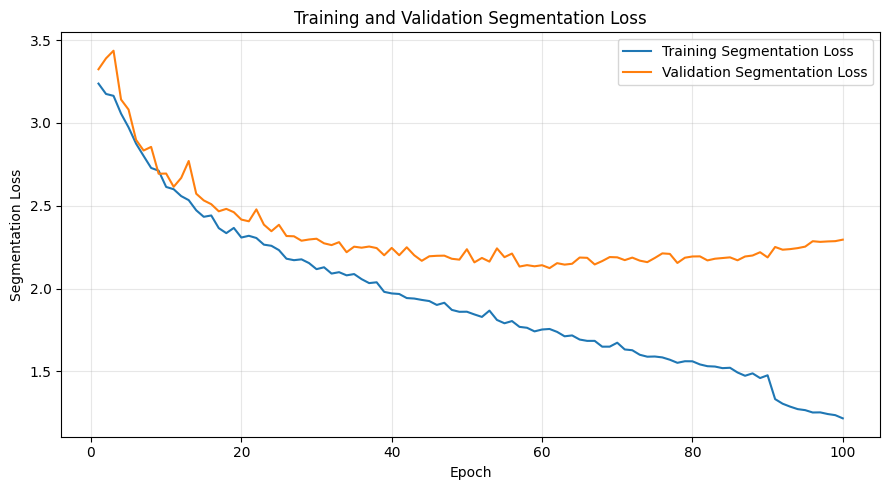

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(
    df["epoch"],
    df["train/seg_loss"],
    label="Training Segmentation Loss"
)

plt.plot(
    df["epoch"],
    df["val/seg_loss"],
    label="Validation Segmentation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Segmentation Loss")
plt.title("Training and Validation Segmentation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

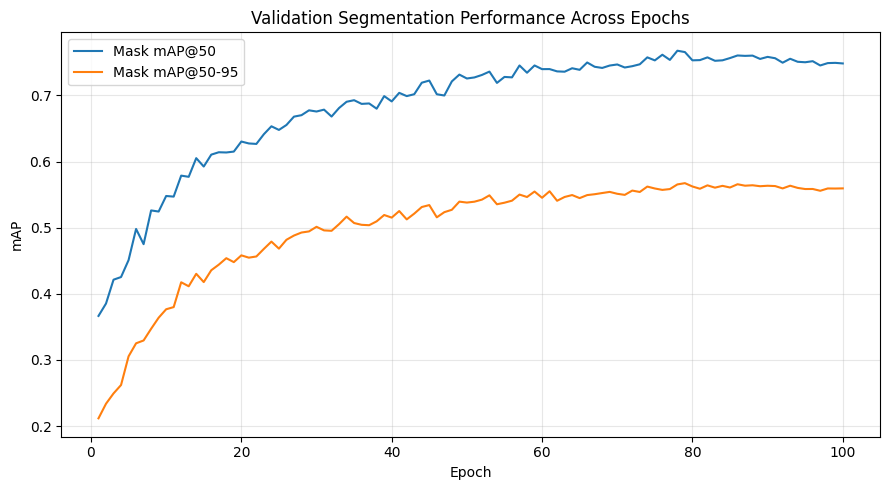

In [47]:
plt.figure(figsize=(9, 5))

plt.plot(
    df["epoch"],
    df["metrics/mAP50(M)"],
    label="Mask mAP@50"
)

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(M)"],
    label="Mask mAP@50-95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation Segmentation Performance Across Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()